##Import Data

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
import os
import seaborn as sns

In [86]:
print("جاري تحميل البيانات")

df=pd.read_csv("/content/archive (2).zip",sep='\t')

print("تم تحميل البيانات")
df.head()

جاري تحميل البيانات
تم تحميل البيانات


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##Data Cleaning

In [88]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [89]:
df['Income'].fillna(df['Income'].mean(),inplace=True)

/tmp/ipykernel_1810/3520889957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].mean(),inplace=True)


In [90]:
print(df.duplicated().sum())

0


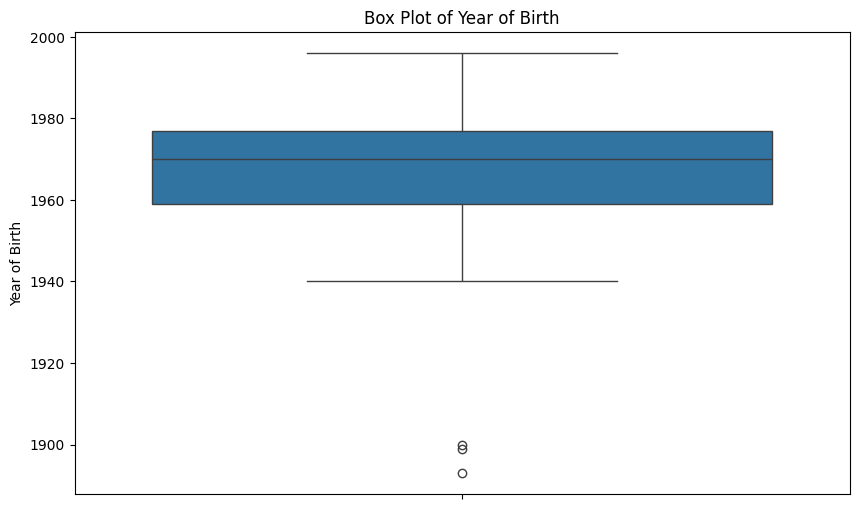

In [91]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Year_Birth'])
plt.title('Box Plot of Year of Birth')
plt.ylabel('Year of Birth')
plt.show()

In [92]:
df = df[df['Year_Birth'] > 1900]

In [93]:
print(df.shape)

(2237, 29)


In [94]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,...,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.0,2237.0,2237.000000
mean,5590.726419,1968.901654,52236.696036,0.444345,0.506482,49.104604,303.995530,26.270451,166.916853,37.523022,...,5.319177,0.072865,0.074654,0.072418,0.064372,0.013411,0.008941,3.0,11.0,0.149307
std,3245.118591,11.701917,25043.111847,0.538467,0.544593,28.956073,336.574382,39.715972,225.661158,54.639909,...,2.426386,0.259974,0.262890,0.259237,0.245469,0.115052,0.094152,0.0,0.0,0.356471
min,0.000000,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2829.000000,1959.000000,35523.000000,0.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5455.000000,1970.000000,51717.000000,0.000000,0.000000,49.000000,174.000000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.000000,1977.000000,68281.000000,1.000000,1.000000,74.000000,504.000000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


##Feature Engineering

In [95]:
df['Age']=2026-df['Year_Birth']
df['Dt_Customer_Years']=2026-pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y').dt.year
df['Total_Spendings']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [96]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Dt_Customer_Years,Total_Spendings
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,69,14,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,72,12,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,61,13,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,42,12,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,45,12,422


In [97]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()
df['Education']=encoder.fit_transform(df[['Education']])
df['Marital_Status']=encoder.fit_transform(df[['Marital_Status']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [98]:
df=df.drop(['Year_Birth','Dt_Customer','ID','Z_Revenue','Z_CostContact'],axis=1)

In [99]:
x=df.drop('Response',axis=1)
y=df['Response']

In [100]:
y.value_counts()

,count
Response,
0,1903
1,334


In [101]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Define the numerical columns to be scaled
# Exclude 'ID', 'Z_CostContact', 'Z_Revenue' as they might not be relevant for scaling or clustering directly
numerical_cols = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
                  'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                  'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
                  'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                  'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Complain',
                  'Age', 'Dt_Customer_Years', 'Total_Spendings']

# Filter numerical_cols to include only columns present in df
numerical_cols = [col for col in numerical_cols if col in df.columns]

x_train = scaler.fit_transform(x_train[numerical_cols])
x_test=scaler.transform(x_test[numerical_cols])

#Unsupervised Learning (Customer Segmentation)

##PCA

In [103]:
print(f"x_train.shape={x_train.shape}")
print(f"x_test.shape={x_test.shape}")

x_train.shape=(1789, 24)
x_test.shape=(448, 24)


In [104]:
from sklearn.decomposition import PCA

pca_1=PCA(n_components=0.80)
x_PCA_train=pca_1.fit_transform(x_train)
x_PCA_test=pca_1.transform(x_test)
print(f"نضغط 25 عامودا الى {pca_1.n_components_} فقط باستخدام خوارزمية PCA")


نضغط 25 عامودا الى 12 فقط باستخدام خوارزمية PCA


In [105]:
variance=pca_1.explained_variance_ratio_
total_variance=sum(variance)

print(f"المجموع : نحن ضغطنا 30 عامودا في {pca_1.n_components_} و مازلنا نحتفض ب{total_variance*100:.2f}% من المعلومات الاساسية")

المجموع : نحن ضغطنا 30 عامودا في 12 و مازلنا نحتفض ب81.14% من المعلومات الاساسية


##KMeans

In [106]:
from sklearn.cluster import KMeans

print("==========================")
print("جاري البحث عن العدد المثالي للمجموعات........")


wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',n_init="auto",random_state=42)
  kmeans.fit(x_PCA_train)
  wcss.append(kmeans.inertia_)

جاري البحث عن العدد المثالي للمجموعات........


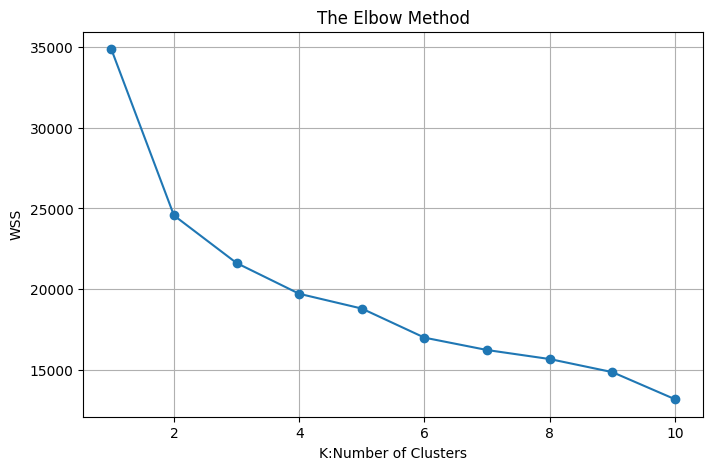

In [107]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,11),wcss,marker='o',linestyle='-')
plt.title('(The Elbow Method)')
plt.xlabel('K:Number of Clusters')
plt.ylabel('WSS')
plt.title('The Elbow Method')
plt.grid()
plt.show()

In [108]:
kmeans=KMeans(n_clusters=2,init='k-means++',n_init="auto",random_state=42)
y_kmeans=kmeans.fit(x_PCA_train)

In [109]:
train_clusters = kmeans.predict(x_PCA_train)
test_clusters  = kmeans.predict(x_PCA_test)

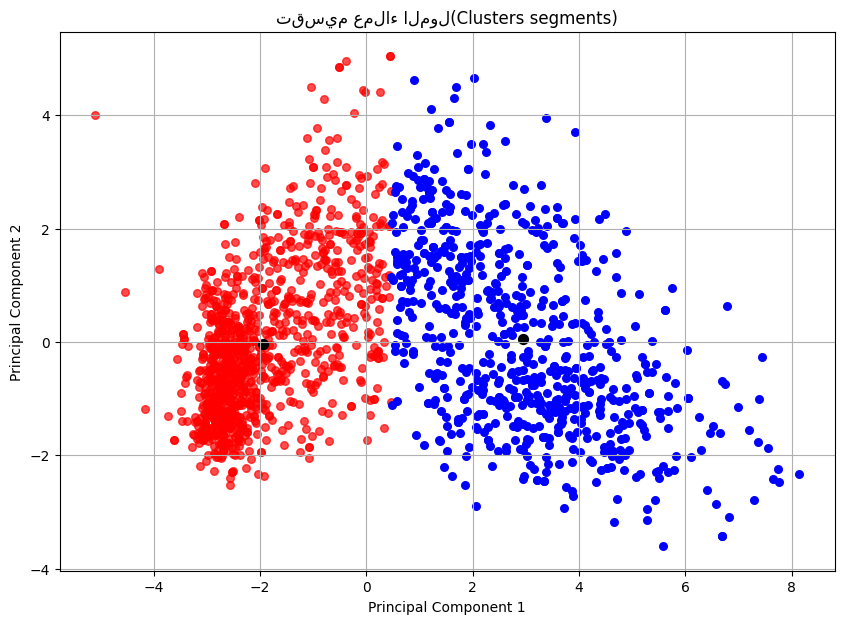

In [110]:
#اللوحة العينية للمجموعات
plt.figure(figsize=(10,7))
plt.scatter(x_PCA_train[kmeans.labels_==0,0],x_PCA_train[kmeans.labels_==0,1],s=30,alpha=0.7,c='red',label='Elite Spenders')
plt.scatter(x_PCA_train[kmeans.labels_==1,0],x_PCA_train[kmeans.labels_==1,1],s=30,c='blue',label='Frugal Youngsters')

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=50,c='black',label='boss (Centroids)')
plt.title('تقسيم عملاء المول(Clusters segments)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

# Supervised Learning (Response Prediction)

##Feature Engineer for S.L

In [111]:

x_train = pd.DataFrame(x_train, columns=numerical_cols)
x_test = pd.DataFrame(x_test, columns=numerical_cols)


x_train['Cluster'] = train_clusters
x_test['Cluster'] = test_clusters

##XGBoost

In [121]:
from sklearn.metrics import accuracy_score
import xgboost as xgb

model_xgb = xgb.XGBClassifier(random_state=42)
model_xgb.fit(x_train, y_train)

acc_xgb = accuracy_score(y_test,model_xgb.predict(x_test))
print(f"Accuracy of XGBoost: {acc_xgb*100:.2f}%")

Accuracy of XGBoost: 87.28%


##Light GBM

In [113]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(random_state=42)
model_lgb.fit(x_train, y_train)
y_pred_lgb = model_lgb.predict(x_test)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"Accuracy of LightGBM: {accuracy_lgb*100:.2f}%")

[LightGBM] [Info] Number of positive: 267, number of negative: 1522
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1798
[LightGBM] [Info] Number of data points in the train set: 1789, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149245 -> initscore=-1.740532
[LightGBM] [Info] Start training from score -1.740532
Accuracy of LightGBM: 88.62%


In [114]:
print(f"Accuracy of LightGBM: {accuracy_lgb*100:.2f}%")

Accuracy of LightGBM: 88.62%


##AdaBoost

In [115]:
import sklearn.ensemble as ensemble

model_ada = ensemble.AdaBoostClassifier(random_state=42)
model_ada.fit(x_train, y_train)
y_pred_ada = model_ada.predict(x_test)
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"Accuracy of AdaBoost: {accuracy_ada*100:.2f}%")


Accuracy of AdaBoost: 86.38%


## Evaluation

In [116]:
from sklearn.metrics import confusion_matrix, classification_report

print("=== XGBoost Model Evaluation ===")
y_pred_xgb = model_xgb.predict(x_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm_xgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

=== XGBoost Model Evaluation ===
Confusion Matrix:
 [[366  15]
 [ 42  25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       381
           1       0.62      0.37      0.47        67

    accuracy                           0.87       448
   macro avg       0.76      0.67      0.70       448
weighted avg       0.86      0.87      0.86       448



In [117]:
print("\n=== LightGBM Model Evaluation ===")
y_pred_lgb = model_lgb.predict(x_test)
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
print("Confusion Matrix:\n", cm_lgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))


=== LightGBM Model Evaluation ===
Confusion Matrix:
 [[368  13]
 [ 38  29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       381
           1       0.69      0.43      0.53        67

    accuracy                           0.89       448
   macro avg       0.80      0.70      0.73       448
weighted avg       0.87      0.89      0.87       448



In [118]:
print("\n=== AdaBoost Model Evaluation ===")
y_pred_ada = model_ada.predict(x_test)
cm_ada = confusion_matrix(y_test, y_pred_ada)
print("Confusion Matrix:\n", cm_ada)
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))


=== AdaBoost Model Evaluation ===
Confusion Matrix:
 [[365  16]
 [ 45  22]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       381
           1       0.58      0.33      0.42        67

    accuracy                           0.86       448
   macro avg       0.73      0.64      0.67       448
weighted avg       0.84      0.86      0.85       448



In [119]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
])

models = {
    "XGBoost": model_xgb,
    "LightGBM": model_lgb,
    "AdaBoost": model_ada
}

for name, model in models.items():

    y_pred = model.predict(x_test)

    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]

results = results.sort_values(by="F1-Score", ascending=False)
result_df=pd.DataFrame(results)
print(result_df)

      Model  Accuracy  Precision    Recall  F1-Score
1  LightGBM  0.886161   0.690476  0.432836  0.532110
0   XGBoost  0.872768   0.625000  0.373134  0.467290
2  AdaBoost  0.863839   0.578947  0.328358  0.419048
